# Commercial PACE Feasibility Underwriting Model
**Target Market:** St. Louis, MO  
**Focus:** Green Infrastructure Investments

### Executive Summary
This geospatial underwriting model evaluates municipal tax and parcel data to identify commercial properties and surface lots prime for Property Assessed Clean Energy (PACE) financing. 

**Core Underwriting Constraints:**
1. **Legal Viability:** The estimated project cost cannot exceed 20% of the property's assessed value (Standard PACE LTV Cap).
2. **Financial Viability:** The project must be cash-flow positive, breaking even through energy savings within a standard 20-year PACE financing term.

In [103]:
import geopandas as gpd
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap  
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. MODEL CONFIGURATION (MACRO ASSUMPTIONS)
# ==========================================
MIN_ASSESSED_VALUE = 150000    
PACE_LTV_CAP = 0.20            
PROJECT_COVERAGE = 0.30        
PACE_TERM_YEARS = 20           

# Economies of Scale Pricing Model
FIXED_MOBILIZATION_COST = 25000 
ROOF_COST_SQFT = 18.00          
PAVEMENT_COST_SQFT = 8.50       

# Externality & ROI Metrics
STORMWATER_RETENTION = 1.5      
ENERGY_SAVINGS = 1.75          
UHI_COOLING_KWH_SQFT = 2.5

### Data Ingestion & Sanitization
Municipal assessor databases frequently contain duplicate records when a single physical parcel has split tax bills. To prevent artificially inflating the Total Addressable Market (TAM), the data undergoes a spatial deduplication process, retaining only the primary tax record (highest assessed value) for each geographic boundary.

In [104]:
# ==========================================
# 2. DATA ACQUISITION & SCRUBBING
# ==========================================
print("1. Loading St. Louis Municipal Data...")
parcels_geo = gpd.read_file("data/Current_Parcels.shp")
parcels_tax = gpd.read_file("data/Parcels_Land_Records.dbf")

print("2. Joining spatial boundaries with tax records...")
# Inner join safely combines map geometry with the tax ledger
city_data = parcels_geo.merge(parcels_tax, on='HANDLE', how='inner')

print("3. Cleaning data & Filtering for Commercial Targets...")
city_data = city_data.sort_values(by='ASMTTOTAL', ascending=False)
city_data = city_data.drop_duplicates(subset=['HANDLE'], keep='first')

commercial_targets = city_data[
    city_data['Zoning'].astype(str).str.match('^[FGHIJK]')
].copy()

commercial_targets = commercial_targets.dropna(subset=['ASMTTOTAL'])
commercial_targets = commercial_targets[commercial_targets['ASMTTOTAL'] >= MIN_ASSESSED_VALUE]
commercial_targets['units'] = pd.to_numeric(commercial_targets['NUMUNITS'], errors='coerce').fillna(0)
commercial_targets = commercial_targets[commercial_targets['units'] == 0]

# Remove tax-exempt/ineligible institutions
ineligible_keywords = [
    'ST LOUIS UNIVERSITY', 'SLU', 'WASHINGTON UNIVERSITY', 'WASH U',
    'CITY OF ST LOUIS', 'ST LOUIS CITY', 'LRA', 'LCRA',
    'U S OF AMERICA', 'USA', 'U.S.A.', 'ORDNANCE PLANT',
    'JUNIOR COLLEGE DIST', 'BOARD OF EDUCATION',
    'BURLINGTON NORTHERN', 'UNION PACIFIC', 'RAILROAD', ' R R CO'
]
exclusion_pattern = '|'.join(ineligible_keywords)
commercial_targets = commercial_targets[
    ~commercial_targets['OWNERNAME_x'].str.contains(exclusion_pattern, na=False, case=False)
].copy()

# SURGICAL DATA FILTER: Remove Surface Parking Lots (No Energy ROI)
commercial_targets = commercial_targets[commercial_targets['AsrLandUse'].astype(str) != '2520']

print(f"✅ Pre-processing complete. {len(commercial_targets)} eligible parcels identified.")

1. Loading St. Louis Municipal Data...
2. Joining spatial boundaries with tax records...
3. Cleaning data & Filtering for Commercial Targets...
✅ Pre-processing complete. 1523 eligible parcels identified.


In [105]:
# ==========================================
# 3. SPATIAL MATH & BASE CALCULATIONS
# ==========================================
print("4. Executing Spatial Math & Structural Logic...")
commercial_targets = commercial_targets.to_crs(epsg=5070)
commercial_targets['parcel_sqft'] = commercial_targets.geometry.area * 10.7639

commercial_targets['stories'] = pd.to_numeric(commercial_targets['BDG1STRYCD'], errors='coerce').fillna(1).clip(lower=1)
commercial_targets['bldg_area'] = pd.to_numeric(commercial_targets['BDG1AREA'], errors='coerce').fillna(0)

# Calculate naive roof area
commercial_targets['raw_roof_sqft'] = commercial_targets['bldg_area'] / commercial_targets['stories']
commercial_targets['max_physical_roof'] = commercial_targets['parcel_sqft'] * 0.80

# Default project assignment
commercial_targets['project_type'] = 'Green Roof'

# CONDO MASTER PARCEL FIX: Impute missing roof area using geographic shape
commercial_targets['project_sqft'] = np.where(
    commercial_targets['raw_roof_sqft'] == 0,
    commercial_targets['parcel_sqft'] * 0.80 * PROJECT_COVERAGE, # Impute Roof based on Geo Shape
    np.minimum(commercial_targets['raw_roof_sqft'], commercial_targets['max_physical_roof']) * PROJECT_COVERAGE
)

# Clean out genuine zero-area anomalies (like GIS slivers)
commercial_targets = commercial_targets[commercial_targets['project_sqft'] > 0]

4. Executing Spatial Math & Structural Logic...


### The Bifurcated Underwriting Engine
This model dynamically adjusts its logic based on the physical characteristics of the parcel:
* **The "Sanity Cap":** Municipal floor-count data is often incomplete. The model calculates theoretical roof size (`Area / Stories`) but enforces a strict geospatial sanity cap—the roof cannot exceed 80% of the physical land parcel.
* **Surface Lot Bifurcation:** If a parcel has zero building area and zero recorded structures, the algorithm automatically flags it as a surface lot, swapping the target infrastructure from Green Roofs to Permeable Pavement and adjusting the cost basis accordingly.

In [106]:
# ==========================================
# 4. ADVANCED ROI ENGINE (SECTOR-SPECIFIC)
# ==========================================
print("5. Applying Sector-Specific Underwriting & Externalities...")

# Base Costs & Allowances (Simplified for Roofs)
commercial_targets['variable_cost'] = ROOF_COST_SQFT
commercial_targets['est_project_cost'] = FIXED_MOBILIZATION_COST + (commercial_targets['project_sqft'] * commercial_targets['variable_cost'])
commercial_targets['max_pace_loan'] = commercial_targets['ASMTTOTAL'] * PACE_LTV_CAP

# Base Externalities
commercial_targets['stormwater_gal_yr'] = commercial_targets['project_sqft'] * STORMWATER_RETENTION
commercial_targets['energy_savings_yr'] = commercial_targets['project_sqft'] * ENERGY_SAVINGS
commercial_targets['uhi_cooling_kwh'] = commercial_targets['project_sqft'] * UHI_COOLING_KWH_SQFT 

# Identify Land Use Sectors
lu_str = commercial_targets['AsrLandUse'].astype(str)
is_garage = lu_str.isin(['2510', '2515'])
is_industrial = lu_str == '5000'
is_multi_family = lu_str == '1115'

# Apply Modifiers
commercial_targets.loc[is_garage, 'project_type'] = 'Green Wall / Deck Retrofit'
commercial_targets.loc[is_garage, 'est_project_cost'] *= 1.25      # Higher structural/plumbing costs
commercial_targets.loc[is_garage, 'energy_savings_yr'] *= 0.60     # Lower insulation value
commercial_targets.loc[is_industrial, 'energy_savings_yr'] *= 1.20 # High impact on uninsulated warehouses
commercial_targets.loc[is_multi_family, 'stormwater_gal_yr'] *= 0.85 # Less new retention needed vs industrial

# Calculate Break-Even
commercial_targets['break_even_years'] = np.where(
    commercial_targets['energy_savings_yr'] > 0,
    commercial_targets['est_project_cost'] / commercial_targets['energy_savings_yr'],
    0
)

# The Two-Pronged Viability Test
legal_check = commercial_targets['max_pace_loan'] >= commercial_targets['est_project_cost']
roi_check = (commercial_targets['break_even_years'] > 0) & (commercial_targets['break_even_years'] <= PACE_TERM_YEARS)

commercial_targets['is_viable'] = legal_check & roi_check
viable_projects = commercial_targets[commercial_targets['is_viable']].copy().to_crs(epsg=4326)

5. Applying Sector-Specific Underwriting & Externalities...


In [107]:
# ==========================================
# 5. MAPPING & EXPORT PREPARATION
# ==========================================
# Add Human-Readable Land Use Mapping
land_use_map = {
    '5000': 'Light Industrial / Manufacturing',
    '3000': 'General Commercial / Retail',
    '1115': 'Multi-Family Residential (9+ Units)',
    '2510': 'Parking Garage',
    '2515': 'Commercial Garage'
}
viable_projects['Land_Use_Description'] = viable_projects['AsrLandUse'].astype(str).map(land_use_map).fillna('Other Commercial')

# Calculate Dynamic Tiers
tier1_threshold = viable_projects['ASMTTOTAL'].quantile(0.75) 
tier2_threshold = viable_projects['ASMTTOTAL'].quantile(0.25) 

def assign_tier(value):
    if value >= tier1_threshold: return 'Tier 1 (Top 25% Assessed Value)', '#feca57' 
    elif value >= tier2_threshold: return 'Tier 2 (Mid-Market Value)', '#2ecc71'       
    else: return 'Tier 3 (Baseline Viable)', '#74b9ff'         

viable_projects['tier_label'], viable_projects['color'] = zip(*viable_projects['ASMTTOTAL'].map(assign_tier))

print("\n📤 Exporting targeted property list to CSV...")
export_df = viable_projects[['SITEADDR_x', 'Land_Use_Description', 'project_type', 'ASMTTOTAL', 'stories', 'project_sqft', 'est_project_cost', 'break_even_years', 'uhi_cooling_kwh', 'stormwater_gal_yr']]
export_df.columns = ['Address', 'Land_Use', 'Project_Type', 'Assessed_Value', 'Stories', 'Green_SqFt', 'Est_Cost', 'Break_Even_Years', 'UHI_Cooling_kWh', 'Stormwater_Gal_Yr']
export_df.sort_values(by='Break_Even_Years', ascending=True).to_csv('viable_pace_targets.csv', index=False)


📤 Exporting targeted property list to CSV...


### Dynamic Categorization & Geospatial Output
To assist business development and sales teams, the surviving target properties are exported to a prioritized CSV. Simultaneously, the data is visualized using a dynamic thresholding model that automatically segments the market into three value tiers, overlaying them onto an interactive heatmap to identify prime commercial corridors.

In [108]:
# ==========================================
# 6. EXECUTIVE SUMMARY & MAPPING
# ==========================================
co2_tons = (viable_projects['uhi_cooling_kwh'].sum() * 1.5) / 2000
cars_off_road = co2_tons / 4.6

print(f"\n📊 --- PORTFOLIO EXECUTIVE SUMMARY ---")
print(f"✅ Identified {len(viable_projects)} viable commercial properties.")
print(f"💰 PACE Capital Opportunity: ${viable_projects['est_project_cost'].sum():,.0f}")
print(f"🌡️ UHI Cooling Mitigated: {viable_projects['uhi_cooling_kwh'].sum():,.0f} kWh/Year")
print(f"💧 Stormwater Retained: {viable_projects['stormwater_gal_yr'].sum():,.0f} Gallons/Year")
print(f"🌳 Carbon Offset: {co2_tons:,.0f} Metric Tons CO2 / Year")
print(f"🚗 Vehicle Equivalent: {cars_off_road:,.0f} cars removed from St. Louis roads")

print("\nGenerating interactive map with Heatmap overlay...")
stl_map = folium.Map(location=[38.6270, -90.1994], zoom_start=13, tiles="CartoDB positron")

heat_data = [[row.geometry.centroid.y, row.geometry.centroid.x] for idx, row in viable_projects.iterrows()]
HeatMap(heat_data, name="Target Density Heatmap", radius=12, blur=18, max_zoom=15,
        gradient={0.4: '#74b9ff', 0.65: '#2ecc71', 1: '#feca57'}).add_to(stl_map)

buildings_layer = folium.FeatureGroup(name="Viable Properties (Polygons)")
top_projects = viable_projects.sort_values(by='break_even_years', ascending=True).head(800)

for idx, row in top_projects.iterrows():
    popup_html = f"""
    <div style="font-family: Arial, sans-serif; min-width: 290px; color: #3a3f3a;">
        <div style="background-color: {row['color']}; color: white; padding: 6px; border-radius: 4px; font-weight: bold; margin-bottom: 8px;">
            {row['tier_label']}
        </div>
        <b>Address:</b> {row['SITEADDR_x']}<br>
        <b>Sector:</b> {row['Land_Use_Description']}<br>
        <b>Project:</b> {row['project_type']}<br>
        <b>Assessed Value:</b> ${row['ASMTTOTAL']:,.0f}<br>
        <hr style="border: 0.5px solid #eee;">
        <h5 style="margin: 4px 0; color: #7f8c8d;">Return on Investment</h5>
        <b>Est. Upgrade Cost:</b> ${row['est_project_cost']:,.0f}<br>
        <b>Energy Savings:</b> ${row['energy_savings_yr']:,.0f}/yr<br>
        <b>Est. Break-Even:</b> {row['break_even_years']:.1f} Years<br>
    </div>
    """
    folium.GeoJson(
        row.geometry,
        style_function=lambda x, color=row['color']: {
            'fillColor': color, 'color': color, 'weight': 1.5, 'fillOpacity': 0.65
        },
        popup=folium.Popup(popup_html, max_width=330)
    ).add_to(buildings_layer) 

buildings_layer.add_to(stl_map)
folium.LayerControl(position='topright').add_to(stl_map)

stl_map.save("pace_feasibility_map.html")
print("Complete! Look for 'pace_feasibility_map.html' in your folder.")
stl_map


📊 --- PORTFOLIO EXECUTIVE SUMMARY ---
✅ Identified 394 viable commercial properties.
💰 PACE Capital Opportunity: $45,780,695
🌡️ UHI Cooling Mitigated: 4,990,374 kWh/Year
💧 Stormwater Retained: 2,934,778 Gallons/Year
🌳 Carbon Offset: 3,743 Metric Tons CO2 / Year
🚗 Vehicle Equivalent: 814 cars removed from St. Louis roads

Generating interactive map with Heatmap overlay...
Complete! Look for 'pace_feasibility_map.html' in your folder.


In [109]:
# ==========================================
# PORTFOLIO ENVIRONMENTAL SUMMARY
# ==========================================
import matplotlib.pyplot as plt

def generate_impact_metrics(df):
    # Calculations based on EPA eGRID SERC Midwest factors
    total_kwh = df['uhi_cooling_kwh'].sum()
    co2_tons = (total_kwh * 1.5) / 2000 
    cars_off_road = co2_tons / 4.6 # Avg passenger vehicle emits 4.6 tons/yr
    
    print("🌍 --- AGGREGATE ENVIRONMENTAL IMPACT ---")
    print(f"Total Carbon Offset: {co2_tons:,.0f} Metric Tons CO2 / Year")
    print(f"Vehicle Equivalent: {cars_off_road:,.0f} Passenger cars removed from St. Louis roads")
    print(f"Stormwater Mitigation: {df['stormwater_gal_yr'].sum():,.0f} Gallons / Year")

# Run the summary on only the viable projects
generate_impact_metrics(viable_projects)

🌍 --- AGGREGATE ENVIRONMENTAL IMPACT ---
Total Carbon Offset: 3,743 Metric Tons CO2 / Year
Vehicle Equivalent: 814 Passenger cars removed from St. Louis roads
Stormwater Mitigation: 2,934,778 Gallons / Year


### Visualizing the Portfolio Opportunity
To effectively communicate the feasibility of Commercial PACE in St. Louis, we must look at the data through three lenses: risk mitigation, market segmentation, and financial lifecycle.

In [110]:
# ==========================================
# STORYTELLING & VISUALIZATIONS
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style for professional reporting
sns.set_theme(style="whitegrid")
# Create a color palette matching the map tiers
tier_colors = {'Tier 1 (Top 25% Assessed Value)': '#feca57', 
               'Tier 2 (Mid-Market Value)': '#2ecc71', 
               'Tier 3 (Baseline Viable)': '#74b9ff'}

### The Underwriting Frontier (Risk Mitigation)
Board members need to know that capital is protected. This scatter plot visualizes our strict legal constraint: projects cannot exceed 20% of the property's assessed value. By plotting the estimated project cost against property value, we can clearly see the "safe zone" where PACE lending is legally viable.

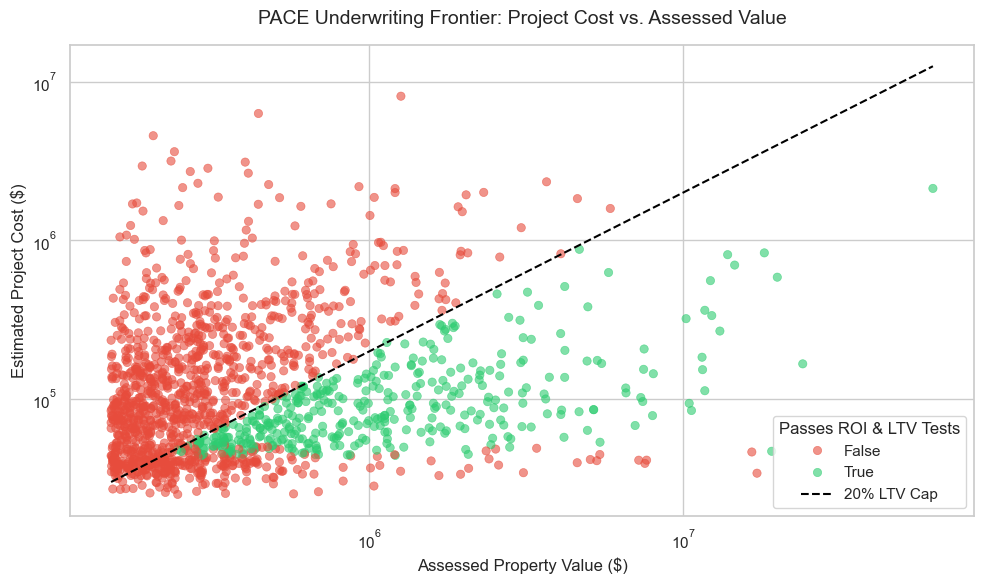

In [111]:
plt.figure(figsize=(10, 6))

# Plot the eligible targets to show the 'Viable' vs 'Inviable' frontier
sns.scatterplot(
    data=commercial_targets, 
    x='ASMTTOTAL', 
    y='est_project_cost', 
    hue='is_viable', 
    palette={True: '#2ecc71', False: '#e74c3c'},
    alpha=0.6,
    edgecolor=None
)

# Draw the 20% LTV Cap Line
x_range = np.linspace(commercial_targets['ASMTTOTAL'].min(), commercial_targets['ASMTTOTAL'].max(), 100)
plt.plot(x_range, x_range * PACE_LTV_CAP, color='black', linestyle='--', label='20% LTV Cap')

plt.title("PACE Underwriting Frontier: Project Cost vs. Assessed Value", fontsize=14, pad=15)
plt.xlabel("Assessed Property Value ($)", fontsize=12)
plt.ylabel("Estimated Project Cost ($)", fontsize=12)
plt.legend(title="Passes ROI & LTV Tests")

# Log scale helps deal with the massive St. Louis industrial properties vs smaller LLCs
plt.xscale('log') 
plt.yscale('log')
plt.tight_layout()
plt.show()

### Market Segmentation (Scale of Impact)
While the massive industrial properties grab headlines, we need to understand where the bulk of the opportunity lies. This dual-axis chart segments our viable portfolio by Tier, comparing the total capital deployment opportunity against the environmental impact (stormwater retention).

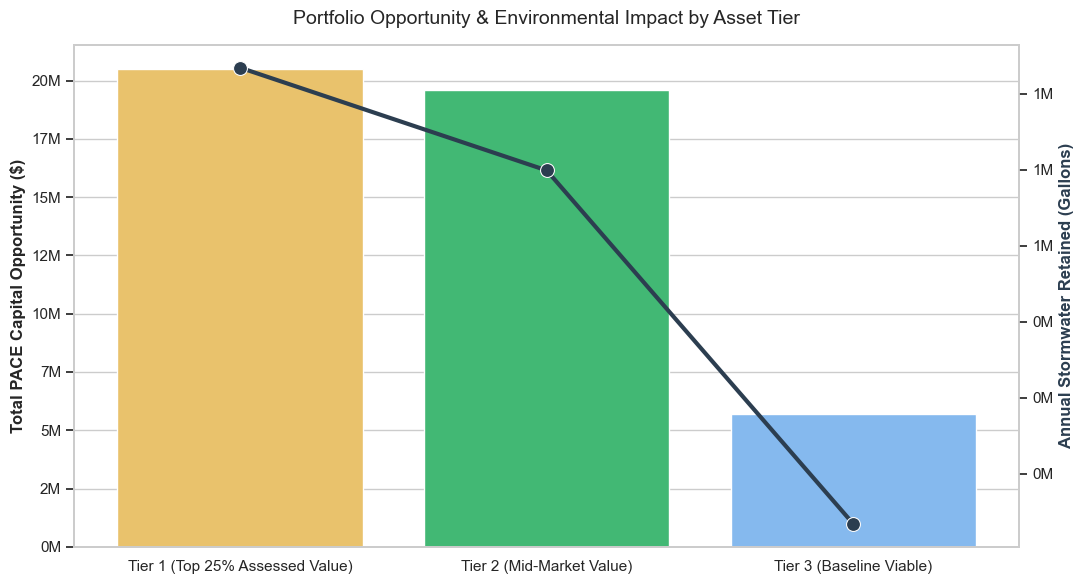

In [112]:
# Aggregate data by Tier
tier_summary = viable_projects.groupby('tier_label').agg({
    'est_project_cost': 'sum',
    'stormwater_gal_yr': 'sum'
}).reset_index()

# Sort to ensure consistent display order
tier_summary['sort_val'] = tier_summary['tier_label'].str.extract('(\d)').astype(int)
tier_summary = tier_summary.sort_values('sort_val')

fig, ax1 = plt.subplots(figsize=(11, 6))

# Primary Axis: Capital Deployment (Bar)
sns.barplot(data=tier_summary, x='tier_label', y='est_project_cost', ax=ax1, palette=tier_colors)
ax1.set_ylabel("Total PACE Capital Opportunity ($)", fontsize=12, fontweight='bold')
ax1.set_xlabel("")
ax1.set_title("Portfolio Opportunity & Environmental Impact by Asset Tier", fontsize=14, pad=15)

# Formatting y-axis to millions for readability
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}M".format(int(x/1e6))))

# Secondary Axis: Stormwater Impact (Line)
ax2 = ax1.twinx()
sns.lineplot(data=tier_summary, x='tier_label', y='stormwater_gal_yr', ax=ax2, color='#2c3e50', marker='o', markersize=10, linewidth=3)
ax2.set_ylabel("Annual Stormwater Retained (Gallons)", color='#2c3e50', fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}M".format(int(x/1e6))))
ax2.grid(False) # Turn off secondary grid lines to keep it clean

plt.tight_layout()
plt.show()

### The Financial Lifecycle (Payback Distribution)
Green infrastructure is an investment, not just an expense. This histogram illustrates the distribution of break-even periods across our viable targets. It proves that the majority of these retrofits will pay for themselves through energy savings well before the standard 20-year PACE financing term expires.

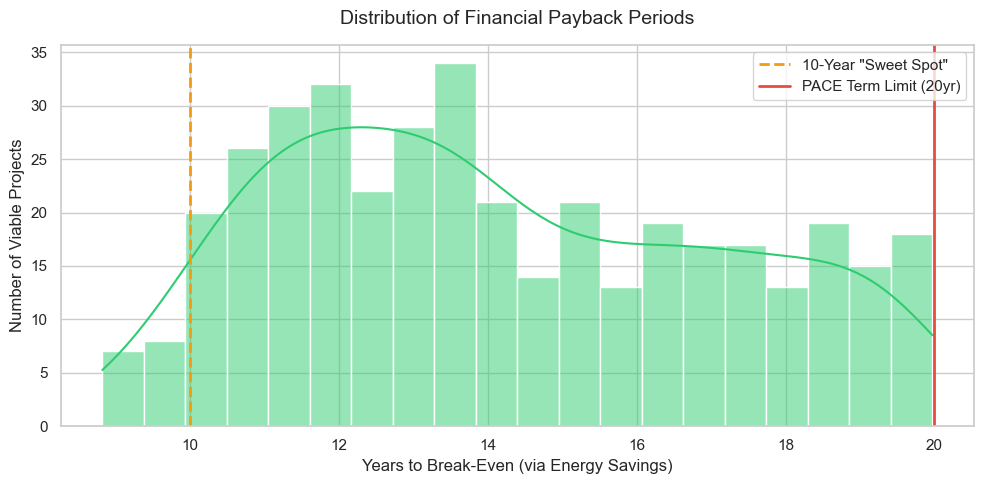

In [113]:
plt.figure(figsize=(10, 5))

# Plot the distribution of break-even years
sns.histplot(viable_projects['break_even_years'], bins=20, kde=True, color='#2ecc71', edgecolor='white')

# Add threshold lines to tell the story
plt.axvline(10, color='#f39c12', linestyle='--', linewidth=2, label='10-Year "Sweet Spot"')
plt.axvline(20, color='#e74c3c', linestyle='-', linewidth=2, label='PACE Term Limit (20yr)')

plt.title("Distribution of Financial Payback Periods", fontsize=14, pad=15)
plt.xlabel("Years to Break-Even (via Energy Savings)", fontsize=12)
plt.ylabel("Number of Viable Projects", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()